In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn import metrics
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import decomposition

df = pd.read_csv("mes_donnees_normalisées.csv", sep=';')

In [2]:
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'E1']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns='E1'))
Y_nan = np.array(df_nan['E1'])
print(X_nan.shape)

(430, 9)


### ACP

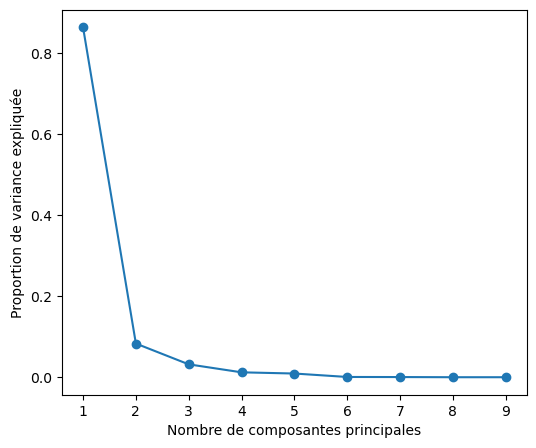

In [ ]:
pca = decomposition.PCA(n_components=9)
pca.fit(X_nan)

fig = plt.figure(figsize=(6, 5))

plt.plot(np.arange(1, 10), pca.explained_variance_ratio_, marker='o')

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Proportion de variance expliquée")

plt.show()

[]

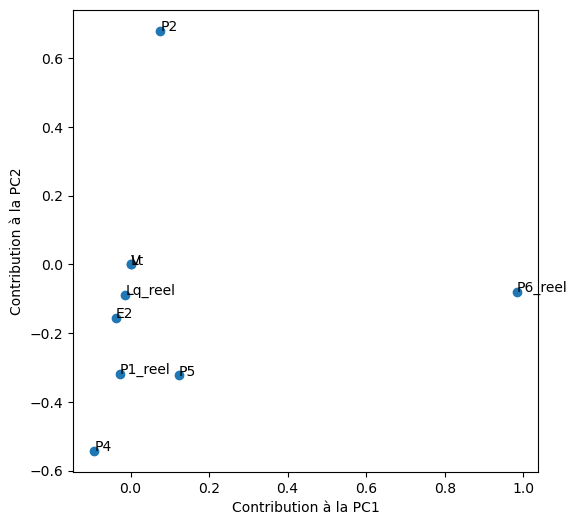

In [4]:
pcs = pca.components_
fig = plt.figure(figsize=(6, 6))

plt.scatter(pcs[0], pcs[1])
for (x_coordinate, y_coordinate, feature_name) in zip(pcs[0], pcs[1], df_propre.columns[:14]):
    plt.text(x_coordinate, y_coordinate, feature_name)                          
    
plt.xlabel("Contribution à la PC1")
plt.ylabel("Contribution à la PC2")

plt.plot()

### Polynomial regression

#### Premier test

In [5]:
polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)

X_poly = polynomial_features.fit_transform(X_nan)


In [6]:
polyreg_ridge = linear_model.Ridge(alpha=0.01)

kf = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
var_list = []

# Boucler sur les folds :
for i, (train_indices, val_indices) in enumerate(kf.split(X_poly)):

    # créer le jeu d'entraînement et le jeu de validation pour ce fold
    X_train_fold = X_poly[train_indices]
    Y_train_fold = Y_nan[train_indices]
    X_val_fold = X_poly[val_indices]
    Y_val_fold = Y_nan[val_indices]

    # entraîner le modèle sur le jeu d'entraînement de ce fold
    polyreg_ridge.fit(X_train_fold, Y_train_fold)

    # prédire sur le jeu de validation du fold
    y_pred_fold = polyreg_ridge.predict(X_val_fold)
    rmse_fold = metrics.root_mean_squared_error(Y_val_fold, y_pred_fold)
    mae_fold = metrics.mean_absolute_error(Y_val_fold, y_pred_fold)
    r2_fold = metrics.r2_score(Y_val_fold, y_pred_fold)
    var_list.append([rmse_fold, mae_fold, r2_fold])

var_array = np.array(var_list)
rmse_avg, mae_avg, r2_avg = np.mean(var_array[:, 0]), np.mean(var_array[:, 1]), np.mean(var_array[:, 2])

print(f"RMSE, MAE et r2 moyens sur le Kfold : {rmse_avg:.2f}; {mae_avg:.2f}; {r2_avg:.2f}.")

RMSE, MAE et r2 moyens sur le Kfold : 0.06; 0.03; 0.86.


#### Deuxième test

In [7]:
##test 2
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'E1', 'E2_moy']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns=['E2_moy']))
Y_nan = np.array(df_nan['E2_moy'])
print(X_nan.shape)

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection

X_poly = polynomial_features.fit_transform(X_nan)

var_list = []
polyreg_ridge = linear_model.Ridge(alpha=0.01)

# Boucler sur les folds :
for i, (train_indices, val_indices) in enumerate(kf.split(X_poly)):

    # créer le jeu d'entraînement et le jeu de validation pour ce fold
    X_train_fold = X_poly[train_indices]
    Y_train_fold = Y_nan[train_indices]
    X_val_fold = X_poly[val_indices]
    Y_val_fold = Y_nan[val_indices]

    # entraîner le modèle sur le jeu d'entraînement de ce fold
    polyreg_ridge.fit(X_train_fold, Y_train_fold)

    # prédire sur le jeu de validation du fold
    y_pred_fold = polyreg_ridge.predict(X_val_fold)
    rmse_fold = metrics.root_mean_squared_error(Y_val_fold, y_pred_fold)
    mae_fold = metrics.mean_absolute_error(Y_val_fold, y_pred_fold)
    r2_fold = metrics.r2_score(Y_val_fold, y_pred_fold)
    var_list.append([rmse_fold, mae_fold, r2_fold])

var_array = np.array(var_list)
rmse_avg, mae_avg, r2_avg = np.mean(var_array[:, 0]), np.mean(var_array[:, 1]), np.mean(var_array[:, 2])

print(f"RMSE, MAE et r2 moyens sur le Kfold : {rmse_avg:.2f}; {mae_avg:.2f}; {r2_avg:.2f}.")

(215, 10)
RMSE, MAE et r2 moyens sur le Kfold : 0.05; 0.04; 0.68.


#### Troisième test

In [8]:
##test 3
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'S_moy', 'sigma_S']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns=['S_moy', 'sigma_S']))
Y_nan = np.array(df_nan['sigma_S'])
print(X_nan.shape)

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection

X_poly = polynomial_features.fit_transform(X_nan)

var_list = []
polyreg_ridge = linear_model.Ridge(alpha=0.01)

# Boucler sur les folds :
for i, (train_indices, val_indices) in enumerate(kf.split(X_poly)):

    # créer le jeu d'entraînement et le jeu de validation pour ce fold
    X_train_fold = X_poly[train_indices]
    Y_train_fold = Y_nan[train_indices]
    X_val_fold = X_poly[val_indices]
    Y_val_fold = Y_nan[val_indices]

    # entraîner le modèle sur le jeu d'entraînement de ce fold
    polyreg_ridge.fit(X_train_fold, Y_train_fold)

    # prédire sur le jeu de validation du fold
    y_pred_fold = polyreg_ridge.predict(X_val_fold)
    rmse_fold = metrics.root_mean_squared_error(Y_val_fold, y_pred_fold)
    mae_fold = metrics.mean_absolute_error(Y_val_fold, y_pred_fold)
    r2_fold = metrics.r2_score(Y_val_fold, y_pred_fold)
    var_list.append([rmse_fold, mae_fold, r2_fold])

var_array = np.array(var_list)
rmse_avg, mae_avg, r2_avg = np.mean(var_array[:, 0]), np.mean(var_array[:, 1]), np.mean(var_array[:, 2])

print(f"RMSE, MAE et r2 moyens sur le Kfold : {rmse_avg:.2f}; {mae_avg:.2f}; {r2_avg:.2f}.")

(430, 9)
RMSE, MAE et r2 moyens sur le Kfold : 0.09; 0.07; 0.84.
